In [3]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import multiprocessing.connection

In [4]:
root_dir = "/media/filming/2025-白海豚/20240824_JM_01/"
metainfo = pd.read_csv("/media/filming/2025-白海豚/20240824_JM_01/FIN_METAINFO.csv", index_col=0)

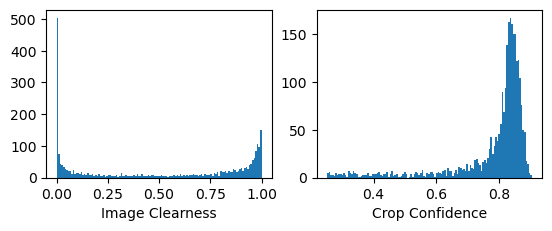

In [5]:
plt.subplot(221)
plt.hist(metainfo.clearness, bins=128)
plt.xlabel("Image Clearness")
plt.subplot(222)
plt.hist(metainfo.crop_conf, bins=128)
plt.xlabel("Crop Confidence")
plt.show()

In [6]:
clearness_threshold = 0.1
crop_conf_threshold = 0.4

In [7]:
total_fin_num = len(metainfo)
selected_clearness_num = np.sum(metainfo.clearness > clearness_threshold)
selected_crop_conf_num = np.sum(metainfo.crop_conf > crop_conf_threshold)
metainfo["select"] = (metainfo.clearness > clearness_threshold ) * (metainfo.crop_conf > crop_conf_threshold)
clearness_annotation = "Clearness > %0.3f \n %d/%d"%(clearness_threshold, selected_clearness_num, total_fin_num)
crop_conf_annotation = "Crop confidence > %0.3f \n %d/%d"%(crop_conf_threshold, selected_crop_conf_num, total_fin_num)
final_selected_num = np.sum(metainfo.select)
final_selected_annotation = "Final selected: %d/%d"%(final_selected_num, total_fin_num)

In [8]:
dest_dir = root_dir + "/FIN/BLUR/"
os.mkdir(dest_dir)
for fin in metainfo.query("clearness<%f"%clearness_threshold)['path']:
    src = root_dir + "/" + fin
    dest =  dest_dir + fin[4:]
    os.symlink(src, dest)

dest_dir = root_dir + "/FIN/LOW_CROP_CONFIDENCE/"
os.mkdir(dest_dir)
for fin in metainfo.query("crop_conf<%f"%crop_conf_threshold)['path']:
    src = root_dir + "/" + fin
    dest = dest_dir + fin[4:]
    os.symlink(src, dest)

dest_dir = root_dir + "/FIN/SELECTED/"
os.mkdir(dest_dir)
for fin in metainfo.query('select==True')['path']:
    src = root_dir + "/" + fin
    dest = dest_dir + fin[4:]
    os.symlink(src, dest)

FileExistsError: [Errno 17] File exists: '/media/filming/2025-白海豚/20240824_JM_01//FIN/BLUR/'

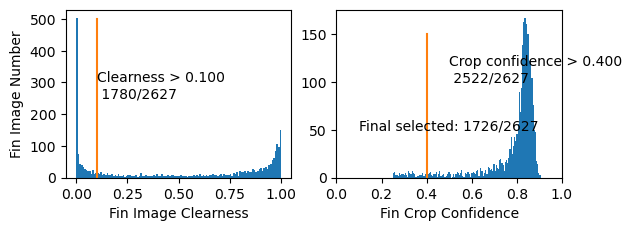

In [9]:
plt.subplot(221)
plt.hist(metainfo.clearness, bins=128)
plt.xlabel("Fin Image Clearness")
plt.ylabel("Fin Image Number")
plt.plot([clearness_threshold, clearness_threshold], [500, 0])
plt.annotate( clearness_annotation, [ clearness_threshold, 250])
plt.subplot(222)
plt.hist(metainfo.crop_conf, bins=128)
plt.xlabel("Fin Crop Confidence")
plt.xlim(0, 1)
plt.annotate( crop_conf_annotation, [ 0.5, 100])
plt.annotate( final_selected_annotation, [0.1, 50])
plt.plot([crop_conf_threshold, crop_conf_threshold], [150, 0])
plt.savefig(root_dir + "/filter.png")
plt.show()

In [21]:
metainfo.query('select==True').to_csv(root_dir + "FILTERTED_FIN_METAINFO.csv")

In [1]:
# todo: filter the same fin were detected multiple time

In [2]:
# move unlabeled dolphin images to low quality folder

In [12]:
lowquality_img  = [i for i in metainfo.orig_img.unique() if i not in metainfo.loc[metainfo['select'] == True, 'orig_img'].unique()]

In [14]:
len(lowquality_img)

771

In [17]:
from pathlib import Path

In [18]:
for img in lowquality_img:
    src = root_dir + "/" + img
    dest_dir = root_dir + "/Quality below 60"
    dest = dest_dir + "/" + img
    if not Path(dest_dir).exists():
        os.mkdir(dest_dir)
    if not os.path.exists(dest):
        os.symlink(src, dest)